# Data quality

1. Missing values
2. Duplicates
3. Outliers
4. Actor distribution
5. Class distribution

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
# ============================================================
# 1. PATH
# ============================================================

DATA_FILE = r"D:\SJU\ML assn\CallConnect\data\processed\features.csv"

EDA_DIR = r"D:\SJU\ML assn\CallConnect\artifacts\eda"
os.makedirs(EDA_DIR, exist_ok=True)

In [5]:
# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_FILE)

metadata_columns = [
    "file_path",
    "actor_id",
    "emotion"
]

feature_columns = [
    col for col in df.columns
    if col not in metadata_columns
]

print("Dataset shape:", df.shape)
print("Number of audio features:", len(feature_columns))

Dataset shape: (1440, 183)
Number of audio features: 180


In [6]:
# ============================================================
# 3. MISSING VALUES
# ============================================================

print("\n" + "=" * 50)
print("1. MISSING VALUES")
print("=" * 50)

missing_total = df.isnull().sum().sum()

print("Total missing values:", missing_total)

if missing_total == 0:
    print("STATUS: PASSED - No missing values found.")
else:
    print("\nColumns with missing values:")
    print(
        df.isnull()
        .sum()
        .loc[lambda x: x > 0]
    )



1. MISSING VALUES
Total missing values: 0
STATUS: PASSED - No missing values found.


In [7]:
# ============================================================
# 4. DUPLICATES
# ============================================================

print("\n" + "=" * 50)
print("2. DUPLICATES")
print("=" * 50)

duplicate_rows = df.duplicated().sum()
duplicate_paths = df["file_path"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate file paths:", duplicate_paths)

if duplicate_rows == 0 and duplicate_paths == 0:
    print("STATUS: PASSED - No duplicates found.")
else:
    print("STATUS: REVIEW REQUIRED")



2. DUPLICATES
Duplicate rows: 0
Duplicate file paths: 0
STATUS: PASSED - No duplicates found.


In [8]:
# ============================================================
# 5. OUTLIER ANALYSIS - IQR METHOD
# ============================================================

print("\n" + "=" * 50)
print("3. OUTLIER ANALYSIS")
print("=" * 50)

outlier_results = []

for feature in feature_columns:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )

    outlier_count = outliers.sum()

    outlier_percentage = (
        outlier_count / len(df)
    ) * 100

    outlier_results.append({
        "feature": feature,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage
    })


outlier_df = pd.DataFrame(outlier_results)

outlier_df = outlier_df.sort_values(
    "outlier_percentage",
    ascending=False
)

print("\nTop 10 features with most statistical outliers:")
print(
    outlier_df.head(10).to_string(index=False)
)

outlier_df.to_csv(
    os.path.join(
        EDA_DIR,
        "outlier_analysis.csv"
    ),
    index=False
)



3. OUTLIER ANALYSIS

Top 10 features with most statistical outliers:
feature  outlier_count  outlier_percentage
  mel_0            297           20.625000
 mel_66            251           17.430556
 mel_78            251           17.430556
  mel_1            250           17.361111
 mel_57            248           17.222222
 mel_84            246           17.083333
 mel_58            245           17.013889
 mel_83            245           17.013889
 mel_86            244           16.944444
 mel_45            244           16.944444


In [9]:
# ============================================================
# 6. OUTLIER SUMMARY
# ============================================================

features_with_outliers = (
    outlier_df["outlier_count"] > 0
).sum()

print("\nFeatures containing statistical outliers:",
      features_with_outliers,
      "out of",
      len(feature_columns))

print(
    "\nNote: Statistical outliers are not automatically"
    " treated as errors. They are only flagged for review."
)




Features containing statistical outliers: 177 out of 180

Note: Statistical outliers are not automatically treated as errors. They are only flagged for review.



4. ACTOR DISTRIBUTION
actor_id
1     60
2     60
3     60
4     60
5     60
6     60
7     60
8     60
9     60
10    60
11    60
12    60
13    60
14    60
15    60
16    60
17    60
18    60
19    60
20    60
21    60
22    60
23    60
24    60
Name: count, dtype: int64

Number of actors: 24
Minimum recordings per actor: 60
Maximum recordings per actor: 60


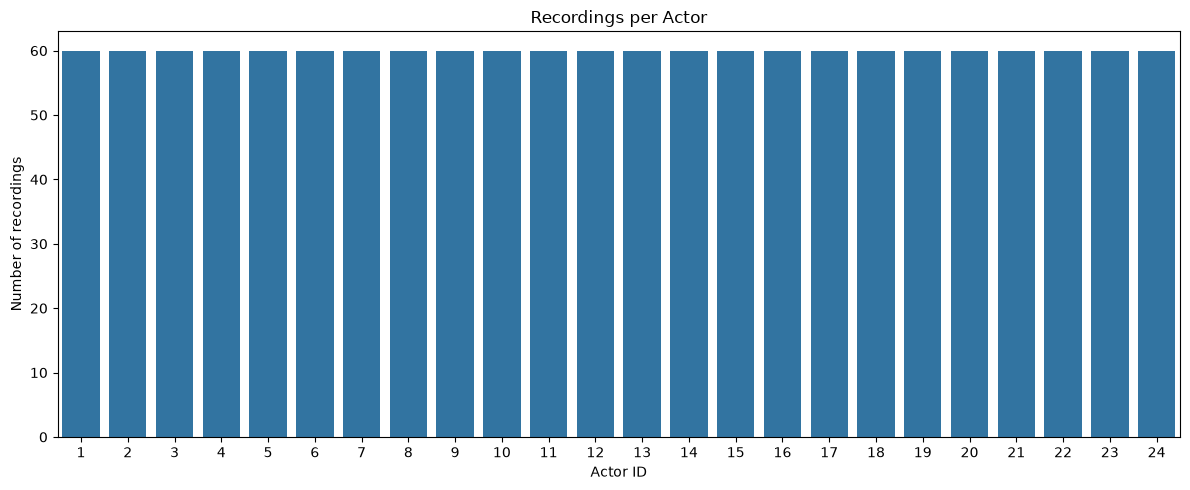

In [27]:
# ============================================================
# 7. ACTOR DISTRIBUTION
# ============================================================

print("\n" + "=" * 50)
print("4. ACTOR DISTRIBUTION")
print("=" * 50)

actor_counts = (
    df["actor_id"]
    .value_counts()
    .sort_index()
)

print(actor_counts)

print("\nNumber of actors:", len(actor_counts))
print("Minimum recordings per actor:", actor_counts.min())
print("Maximum recordings per actor:", actor_counts.max())

plt.figure(figsize=(12, 5))

sns.barplot(
    x=actor_counts.index,
    y=actor_counts.values
)

plt.title("Recordings per Actor")
plt.xlabel("Actor ID")
plt.ylabel("Number of recordings")

plt.tight_layout()

plt.savefig(
    os.path.join(
        EDA_DIR,
        "actor_distribution.png"
    ),
    dpi=150
)

plt.show()
plt.close()





5. CLASS DISTRIBUTION
emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64

Largest class: angry - 192
Smallest class: neutral - 96
Class imbalance ratio: 2.00:1


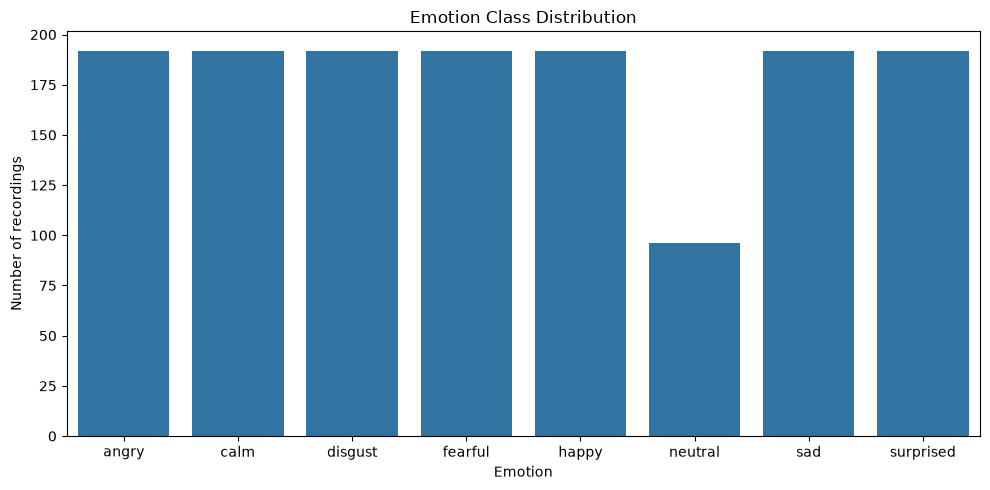

In [28]:
# ============================================================
# 8. CLASS / EMOTION DISTRIBUTION
# ============================================================

print("\n" + "=" * 50)
print("5. CLASS DISTRIBUTION")
print("=" * 50)

class_counts = (
    df["emotion"]
    .value_counts()
    .sort_index()
)

print(class_counts)

print("\nLargest class:",
      class_counts.idxmax(),
      "-",
      class_counts.max())

print("Smallest class:",
      class_counts.idxmin(),
      "-",
      class_counts.min())

imbalance_ratio = (
    class_counts.max() /
    class_counts.min()
)

print(
    f"Class imbalance ratio: {imbalance_ratio:.2f}:1"
)


plt.figure(figsize=(10, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of recordings")

plt.tight_layout()

plt.savefig(
    os.path.join(
        EDA_DIR,
        "class_distribution.png"
    ),
    dpi=150
)

plt.show()
plt.close()




In [12]:
# ============================================================
# 9. SAVE DATA QUALITY SUMMARY
# ============================================================

summary = f"""
DATA QUALITY SUMMARY
====================

Dataset shape:
Rows: {df.shape[0]}
Columns: {df.shape[1]}
Audio features: {len(feature_columns)}

Missing values:
{missing_total}

Duplicate rows:
{duplicate_rows}

Duplicate file paths:
{duplicate_paths}

Actors:
{len(actor_counts)}

Minimum recordings per actor:
{actor_counts.min()}

Maximum recordings per actor:
{actor_counts.max()}

Classes:
{len(class_counts)}

Largest class:
{class_counts.idxmax()} ({class_counts.max()})

Smallest class:
{class_counts.idxmin()} ({class_counts.min()})

Class imbalance ratio:
{imbalance_ratio:.2f}:1

Features with statistical outliers:
{features_with_outliers} / {len(feature_columns)}
"""

with open(
    os.path.join(
        EDA_DIR,
        "data_quality_summary.txt"
    ),
    "w"
) as f:
    f.write(summary)

print("\n" + "=" * 50)
print("DATA QUALITY ANALYSIS COMPLETE")
print("=" * 50)

print("Results saved to:")
print(EDA_DIR)


DATA QUALITY ANALYSIS COMPLETE
Results saved to:
D:\SJU\ML assn\CallConnect\artifacts\eda


# Statistical EDA

1. Distribution
2. Skewness
3. Mean/median/range
4. Correlation
5. Feature interactions

In [17]:
# ============================================================
# STATISTICAL EDA
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [18]:
# ============================================================
# 1. PATHS AND DATA
# ============================================================

DATA_FILE = r"D:\SJU\ML assn\CallConnect\data\processed\features.csv"

EDA_DIR = r"D:\SJU\ML assn\CallConnect\artifacts\eda"
os.makedirs(EDA_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)

metadata_columns = [
    "file_path",
    "actor_id",
    "emotion"
]

feature_columns = [
    col for col in df.columns
    if col not in metadata_columns
]

print("Dataset:", df.shape)
print("Audio features:", len(feature_columns))



Dataset: (1440, 183)
Audio features: 180



1. FEATURE DISTRIBUTION


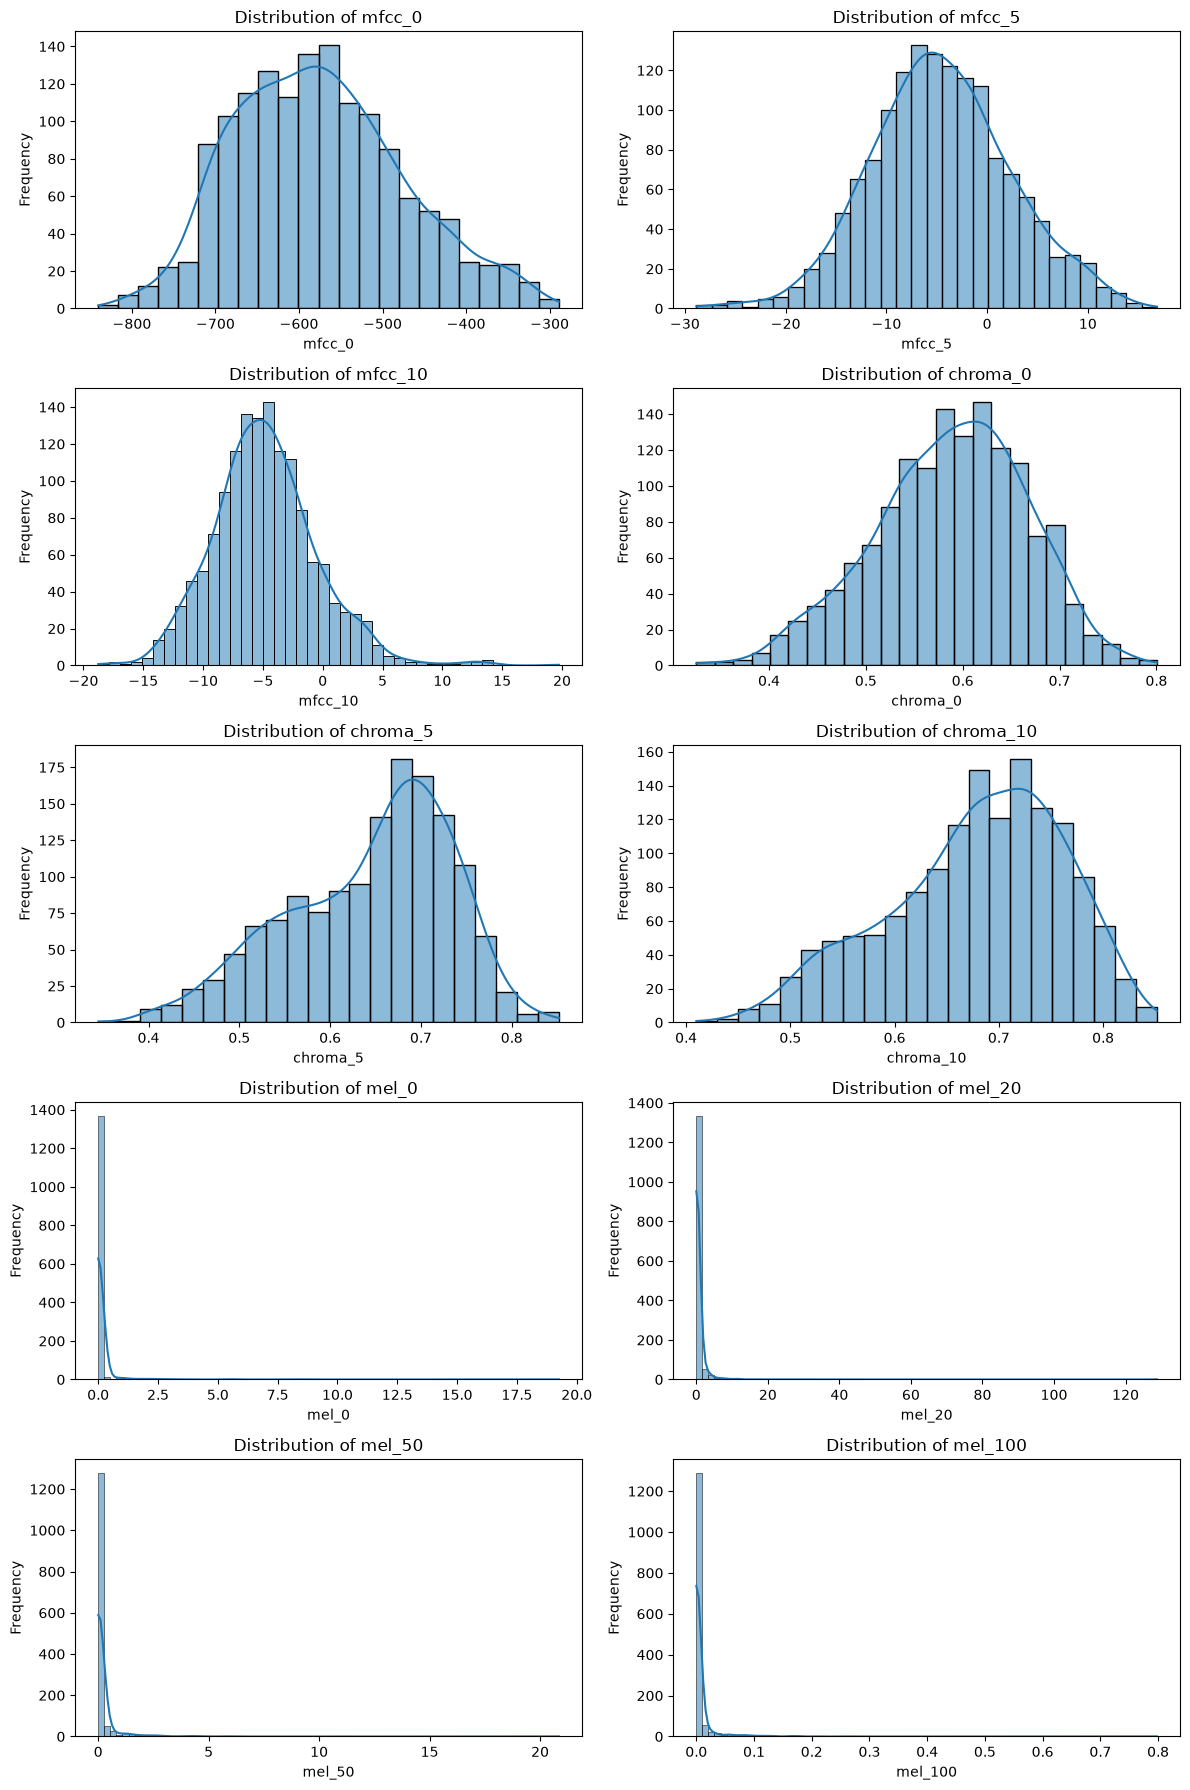

In [19]:
# ============================================================
# FEATURE DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("1. FEATURE DISTRIBUTION")
print("=" * 60)

selected_features = [
    "mfcc_0",
    "mfcc_5",
    "mfcc_10",
    "chroma_0",
    "chroma_5",
    "chroma_10",
    "mel_0",
    "mel_20",
    "mel_50",
    "mel_100"
]

fig, axes = plt.subplots(
    5, 2,
    figsize=(12, 18)
)

for ax, feature in zip(
    axes.flat,
    selected_features
):

    sns.histplot(
        df[feature],
        kde=True,
        ax=ax
    )

    ax.set_title(
        f"Distribution of {feature}"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")


plt.tight_layout()

plt.savefig(
    os.path.join(
        EDA_DIR,
        "feature_distributions.png"
    ),
    dpi=150
)

plt.show()
plt.close()


2. SKEWNESS ANALYSIS

Top 15 most skewed features:
feature  skewness
 mel_63 34.583660
 mel_20 27.499201
 mel_62 27.116261
 mel_89 24.305017
 mel_55 23.801572
 mel_32 23.389791
 mel_92 22.982781
 mel_19 21.778602
mel_115 20.309863
 mel_75 19.653012
 mel_88 19.051499
 mel_91 18.771589
 mel_29 18.763701
 mel_30 18.726647
  mel_1 18.073537


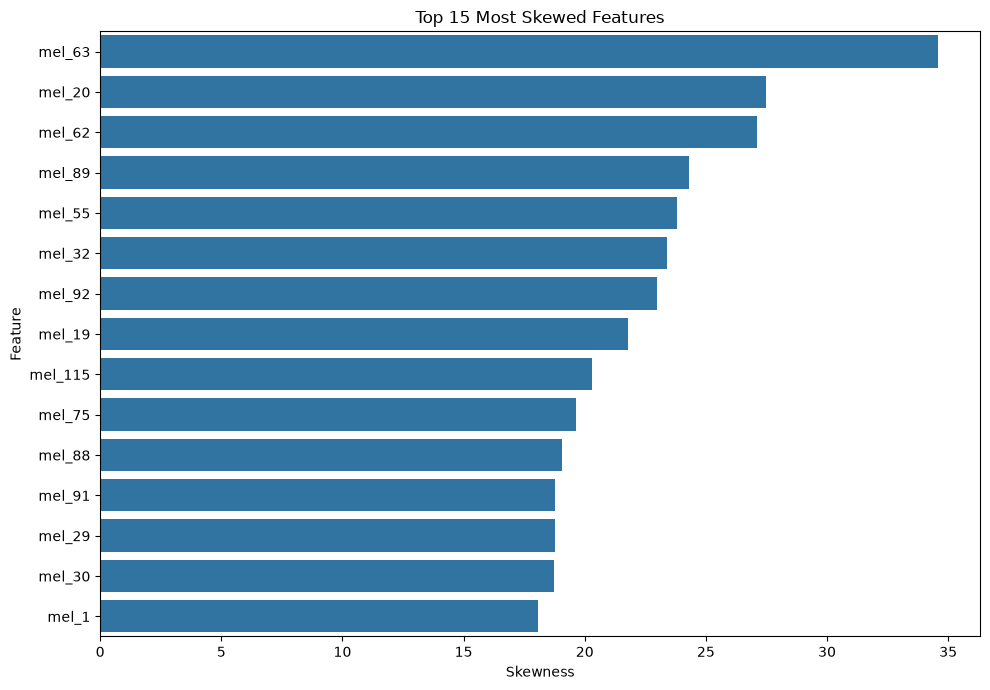

In [20]:
# ============================================================
# 3. SKEWNESS
# ============================================================

print("\n" + "=" * 60)
print("2. SKEWNESS ANALYSIS")
print("=" * 60)

skewness = (
    df[feature_columns]
    .skew()
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

skew_df = pd.DataFrame({
    "feature": skewness.index,
    "skewness": skewness.values
})

print("\nTop 15 most skewed features:")
print(
    skew_df.head(15).to_string(
        index=False
    )
)

# Save complete skewness results
skew_df.to_csv(
    os.path.join(
        EDA_DIR,
        "skewness_analysis.csv"
    ),
    index=False
)


# Plot top 15
top_skewed = skew_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_skewed,
    x="skewness",
    y="feature"
)

plt.title(
    "Top 15 Most Skewed Features"
)

plt.xlabel("Skewness")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(
        EDA_DIR,
        "skewness.png"
    ),
    dpi=150
)

plt.show()
plt.close()







In [21]:
# ============================================================
# 4. MEAN / MEDIAN / RANGE
# ============================================================

print("\n" + "=" * 60)
print("3. MEAN / MEDIAN / RANGE")
print("=" * 60)

statistics_df = pd.DataFrame({
    "mean": df[feature_columns].mean(),
    "median": df[feature_columns].median(),
    "minimum": df[feature_columns].min(),
    "maximum": df[feature_columns].max()
})

statistics_df["range"] = (
    statistics_df["maximum"] -
    statistics_df["minimum"]
)

statistics_df = statistics_df.reset_index()

statistics_df = statistics_df.rename(
    columns={"index": "feature"}
)

print("\nFeature statistics:")
print(
    statistics_df.head(20).to_string(
        index=False
    )
)

statistics_df.to_csv(
    os.path.join(
        EDA_DIR,
        "feature_statistics.csv"
    ),
    index=False
)




3. MEAN / MEDIAN / RANGE

Feature statistics:
feature        mean      median     minimum     maximum      range
 mfcc_0 -575.724890 -581.782375 -840.298900 -288.908570 551.390330
 mfcc_1   43.015615   43.271443  -15.763602   92.419426 108.183028
 mfcc_2   -6.807220   -6.517773  -53.644497   29.445932  83.090429
 mfcc_3    9.110140    8.465940  -16.059706   34.659397  50.719103
 mfcc_4   -5.417115   -5.423718  -31.648159   15.992023  47.640182
 mfcc_5   -4.559073   -4.830462  -28.866951   16.860434  45.727385
 mfcc_6  -10.817722  -11.304759  -28.207846    6.093812  34.301658
 mfcc_7   -8.345785   -8.349818  -28.867643    8.124224  36.991867
 mfcc_8   -3.991687   -4.051431  -25.828419   21.637259  47.465678
 mfcc_9   -2.586871   -2.671282  -16.020145   17.196276  33.216421
mfcc_10   -4.806991   -5.069049  -18.766317   19.734472  38.500789
mfcc_11   -1.061357   -1.234874  -13.871189   20.518148  34.389337
mfcc_12   -2.497878   -2.616641  -12.927099   19.124903  32.052002
mfcc_13   -1.28

In [22]:
# ============================================================
# 5. CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("4. CORRELATION ANALYSIS")
print("=" * 60)

# Calculate correlation across ALL 180 features
corr = df[feature_columns].corr()

# Find strongest feature pairs
corr_abs = corr.abs()

upper_triangle = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

top_pairs = (
    upper_triangle
    .stack()
    .sort_values(
        ascending=False
    )
)

correlation_rows = []

for (feature1, feature2), abs_value in top_pairs.head(20).items():

    correlation_rows.append({
        "feature_1": feature1,
        "feature_2": feature2,
        "correlation": corr.loc[
            feature1,
            feature2
        ],
        "absolute_correlation": abs_value
    })


correlation_df = pd.DataFrame(
    correlation_rows
)

print("\nTop 20 correlated feature pairs:")
print(
    correlation_df.to_string(
        index=False
    )
)

correlation_df.to_csv(
    os.path.join(
        EDA_DIR,
        "top_correlated_features.csv"
    ),
    index=False
)






4. CORRELATION ANALYSIS

Top 20 correlated feature pairs:
feature_1 feature_2  correlation  absolute_correlation
  mel_109   mel_110     0.965011              0.965011
   mel_91    mel_92     0.963204              0.963204
   mel_88    mel_89     0.961476              0.961476
  mel_120   mel_121     0.953620              0.953620
  mel_113   mel_114     0.947753              0.947753
  mel_112   mel_113     0.946719              0.946719
  mel_121   mel_122     0.945562              0.945562
  mel_126   mel_127     0.945056              0.945056
  mel_124   mel_125     0.944071              0.944071
  mel_118   mel_119     0.939799              0.939799
  mel_125   mel_126     0.937535              0.937535
   mel_89    mel_90     0.935507              0.935507
   mel_62    mel_63     0.935435              0.935435
  mel_117   mel_118     0.933207              0.933207
   mel_79    mel_80     0.931096              0.931096
  mel_116   mel_117     0.930465              0.930465
  mel_

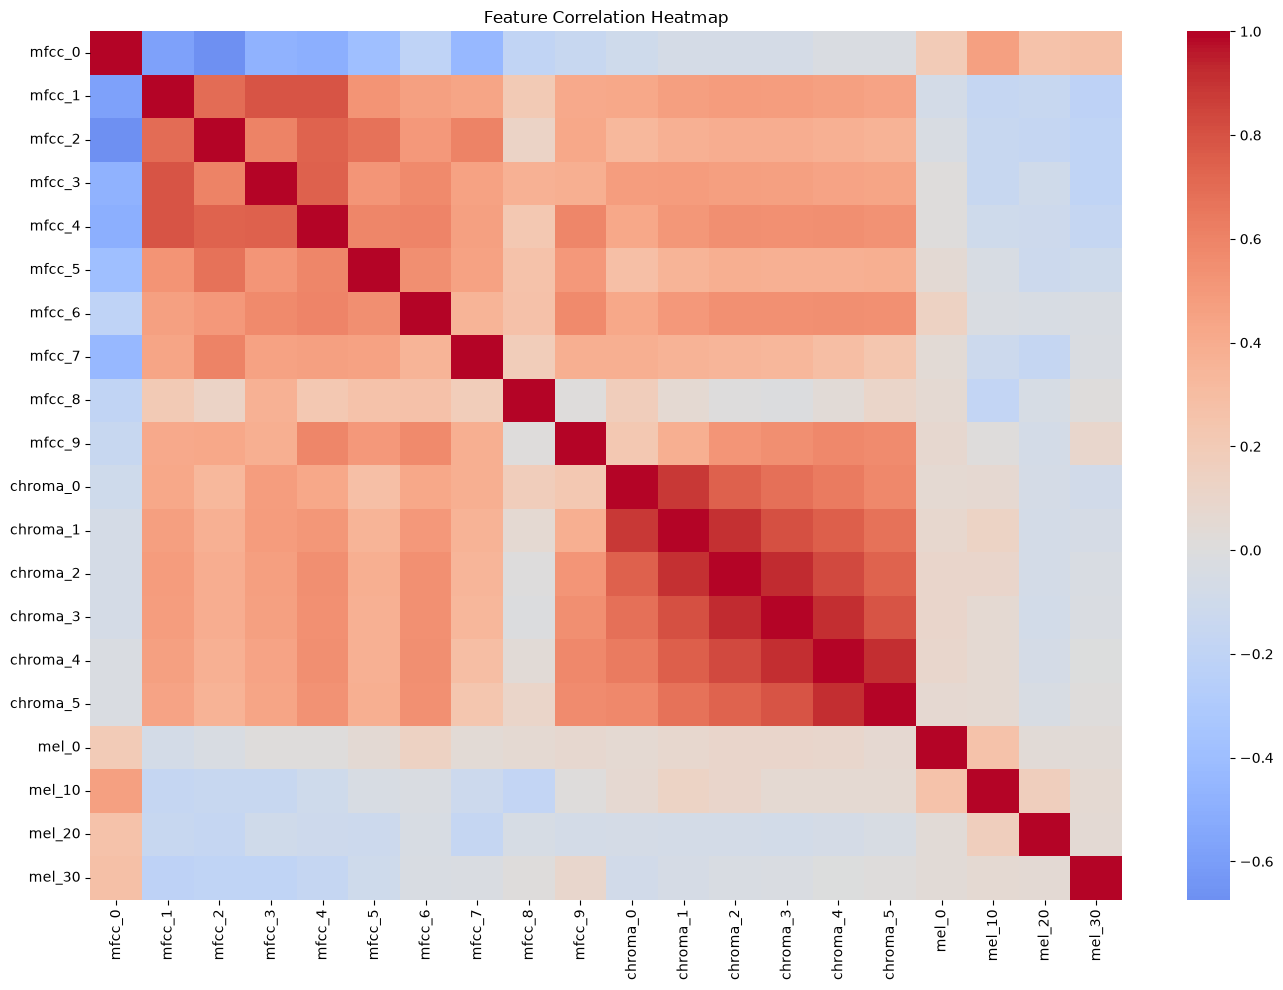

In [23]:
# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================

# Use a manageable subset for visualization
heatmap_features = [
    "mfcc_0",
    "mfcc_1",
    "mfcc_2",
    "mfcc_3",
    "mfcc_4",
    "mfcc_5",
    "mfcc_6",
    "mfcc_7",
    "mfcc_8",
    "mfcc_9",
    "chroma_0",
    "chroma_1",
    "chroma_2",
    "chroma_3",
    "chroma_4",
    "chroma_5",
    "mel_0",
    "mel_10",
    "mel_20",
    "mel_30"
]

plt.figure(
    figsize=(14, 10)
)

sns.heatmap(
    df[heatmap_features].corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        EDA_DIR,
        "correlation_heatmap.png"
    ),
    dpi=150
)

plt.show()
plt.close()





5. FEATURE INTERACTION
Strongest pair: mel_109 vs mel_110
Correlation: 0.965


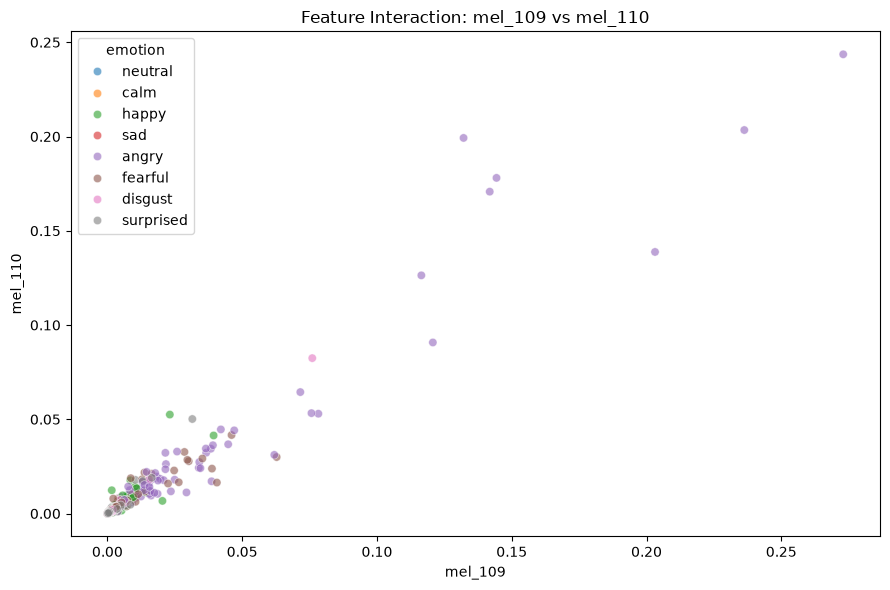

In [24]:
# ============================================================
# 7. FEATURE INTERACTION
# ============================================================

print("\n" + "=" * 60)
print("5. FEATURE INTERACTION")
print("=" * 60)

# Take the strongest correlated pair
feature_1 = correlation_df.iloc[0]["feature_1"]
feature_2 = correlation_df.iloc[0]["feature_2"]

print(
    f"Strongest pair: {feature_1} vs {feature_2}"
)

print(
    f"Correlation: "
    f"{correlation_df.iloc[0]['correlation']:.3f}"
)


# Scatter plot
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x=feature_1,
    y=feature_2,
    hue="emotion",
    alpha=0.6
)

plt.title(
    f"Feature Interaction: {feature_1} vs {feature_2}"
)

plt.xlabel(feature_1)
plt.ylabel(feature_2)

plt.tight_layout()

plt.savefig(
    os.path.join(
        EDA_DIR,
        "feature_interaction.png"
    ),
    dpi=150
)

plt.show()
plt.close()


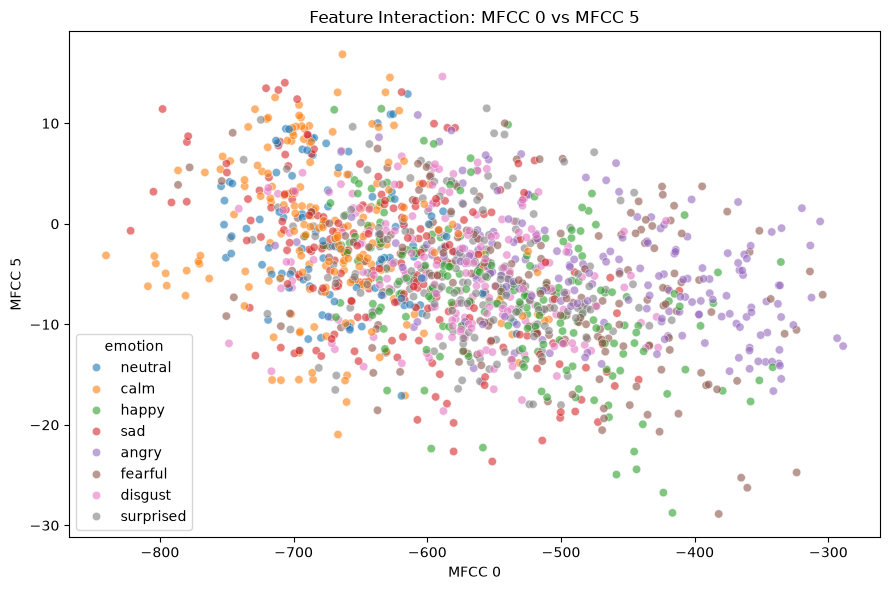

In [25]:
#============================================================
# 8. FEATURE INTERACTION BY EMOTION
# ============================================================

# A second interaction using two representative MFCC features

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="mfcc_0",
    y="mfcc_5",
    hue="emotion",
    alpha=0.6
)

plt.title(
    "Feature Interaction: MFCC 0 vs MFCC 5"
)

plt.xlabel("MFCC 0")
plt.ylabel("MFCC 5")

plt.tight_layout()

plt.savefig(
    os.path.join(
        EDA_DIR,
        "mfcc_feature_interaction.png"
    ),
    dpi=150
)

plt.show()
plt.close()


In [26]:
# ============================================================
# 9. SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("STATISTICAL EDA COMPLETE")
print("=" * 60)

print("\nOutputs saved to:")
print(EDA_DIR)

print("\nGenerated files:")
print("- feature_distributions.png")
print("- skewness_analysis.csv")
print("- skewness.png")
print("- feature_statistics.csv")
print("- top_correlated_features.csv")
print("- correlation_heatmap.png")
print("- feature_interaction.png")
print("- mfcc_feature_interaction.png")


STATISTICAL EDA COMPLETE

Outputs saved to:
D:\SJU\ML assn\CallConnect\artifacts\eda

Generated files:
- feature_distributions.png
- skewness_analysis.csv
- skewness.png
- feature_statistics.csv
- top_correlated_features.csv
- correlation_heatmap.png
- feature_interaction.png
- mfcc_feature_interaction.png


# Interpretation

1. Emotion-specific patterns
2. Redundant features
3. Class distribution impact
4. Top 3 actionable insights

In [ ]:
# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)


# ============================================================
# 1. EMOTION-SPECIFIC PATTERNS
# ============================================================

print("\n1. EMOTION-SPECIFIC PATTERNS")
print("-" * 60)

# Representative features
emotion_features = [
    "mfcc_0",
    "mfcc_5",
    "mfcc_10",
    "chroma_0",
    "mel_0"
]

emotion_means = (
    df.groupby("emotion")[emotion_features]
    .mean()
)

print("\nMean feature values by emotion:")
print(emotion_means.round(3))

# Calculate range between emotions for each feature
emotion_range = (
    emotion_means.max() -
    emotion_means.min()
).sort_values(ascending=False)

print("\nFeatures showing the largest difference between emotions:")
print(
    emotion_range.head(5).round(3)
)

print(
    "\nInterpretation:"
)

print(
    "The differences in feature means across emotions "
    "indicate that some acoustic characteristics vary "
    "between emotional classes. These features may therefore "
    "contain useful information for emotion classification."
)






In [ ]:
# ============================================================
# 2. REDUNDANT FEATURES
# ============================================================

print("\n2. REDUNDANT FEATURES")
print("-" * 60)

# Use the previously calculated correlation matrix
corr_abs = corr.abs()

upper_triangle = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

# Correlations above 0.90
redundant_pairs = high_corr_pairs[
    high_corr_pairs >= 0.90
]

print(
    f"Number of feature pairs with "
    f"|correlation| >= 0.90: {len(redundant_pairs)}"
)

print("\nTop redundant feature pairs:")

for (feature1, feature2), value in (
    redundant_pairs.head(10).items()
):

    print(
        f"{feature1} <-> {feature2} : "
        f"{value:.3f}"
    )

print(
    "\nInterpretation:"
)

if len(redundant_pairs) > 0:

    print(
        "Several extracted features show very high "
        "correlation with each other. This suggests that "
        "some features contain overlapping information. "
        "Feature selection or dimensionality reduction "
        "could therefore be considered during modelling."
    )

else:

    print(
        "No feature pairs exceeded the 0.90 correlation "
        "threshold. Strong redundancy was therefore not "
        "observed at this threshold."
    )



In [ ]:
# ============================================================
# 3. CLASS DISTRIBUTION IMPACT
# ============================================================

print("\n3. CLASS DISTRIBUTION IMPACT")
print("-" * 60)

class_counts = (
    df["emotion"]
    .value_counts()
    .sort_values(ascending=False)
)

largest_class = class_counts.index[0]
smallest_class = class_counts.index[-1]

largest_count = class_counts.iloc[0]
smallest_count = class_counts.iloc[-1]

ratio = (
    largest_count /
    smallest_count
)

print("Class distribution:")
print(class_counts)

print(
    f"\nLargest class  : {largest_class} "
    f"({largest_count})"
)

print(
    f"Smallest class : {smallest_class} "
    f"({smallest_count})"
)

print(
    f"Class ratio    : {ratio:.2f}:1"
)

print(
    "\nInterpretation:"
)

print(
    f"The {smallest_class} class contains fewer recordings "
    f"than the other emotion classes. The class distribution "
    f"should therefore be considered when evaluating the "
    f"classification model. Accuracy alone may not fully "
    f"represent performance across all emotion classes, so "
    f"class-wise metrics such as precision, recall and F1-score "
    f"should also be examined."
)



In [ ]:
# ============================================================
# 4. TOP 3 ACTIONABLE INSIGHTS
# ============================================================

print("\n4. TOP 3 ACTIONABLE INSIGHTS")
print("-" * 60)

# Most emotion-varying feature
top_emotion_feature = emotion_range.index[0]

# Strongest correlation
strongest_pair = correlation_df.iloc[0]

# Most skewed feature
most_skewed = skew_df.iloc[0]


print("\nInsight 1 - Emotion-specific features")
print(
    f"{top_emotion_feature} shows the largest difference "
    f"in mean value across the analysed emotion classes. "
    f"This suggests that this feature may contain useful "
    f"information for distinguishing emotions."
)


print("\nInsight 2 - Feature redundancy")
print(
    f"The strongest correlation was observed between "
    f"{strongest_pair['feature_1']} and "
    f"{strongest_pair['feature_2']} "
    f"(correlation = "
    f"{strongest_pair['correlation']:.3f}). "
    f"This indicates that some extracted audio features "
    f"may contain overlapping information."
)


print("\nInsight 3 - Class distribution")
print(
    f"The {smallest_class} class has the fewest recordings "
    f"({smallest_count}), compared with {largest_class} "
    f"({largest_count}). The imbalance should be considered "
    f"during model evaluation, particularly when comparing "
    f"class-wise performance."
)




In [ ]:
# ============================================================
# 5. SAVE INTERPRETATION
# ============================================================

interpretation_file = os.path.join(
    EDA_DIR,
    "interpretation.txt"
)

with open(
    interpretation_file,
    "w"
) as f:

    f.write(
        "INTERPRETATION\n"
        "==============\n\n"
    )

    f.write(
        "1. EMOTION-SPECIFIC PATTERNS\n"
    )

    f.write(
        f"{top_emotion_feature} shows the largest "
        "difference in mean value across the analysed "
        "emotion classes.\n\n"
    )

    f.write(
        "2. REDUNDANT FEATURES\n"
    )

    f.write(
        f"The strongest correlation was between "
        f"{strongest_pair['feature_1']} and "
        f"{strongest_pair['feature_2']} "
        f"({strongest_pair['correlation']:.3f}).\n\n"
    )

    f.write(
        "3. CLASS DISTRIBUTION IMPACT\n"
    )

    f.write(
        f"The smallest class was {smallest_class} "
        f"with {smallest_count} recordings, while "
        f"the largest class was {largest_class} "
        f"with {largest_count} recordings.\n\n"
    )

    f.write(
        "TOP 3 ACTIONABLE INSIGHTS\n"
        "--------------------------\n"
        f"1. {top_emotion_feature} shows notable "
        "variation across emotion classes.\n"
        f"2. {strongest_pair['feature_1']} and "
        f"{strongest_pair['feature_2']} show the "
        f"strongest feature correlation.\n"
        f"3. The class distribution should be considered "
        "when evaluating model performance.\n"
    )

print(
    f"\nInterpretation saved to: "
    f"{interpretation_file}"
)